#IMPORTACION DE LAS LIBRERIAS

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
import string
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

#3. Recolección y comprensión de los datos

### 3.2 — Proceso de adquisición de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Configuración visual para gráficos
sns.set_theme(style="whitegrid")
print("Cargando los datasets...")
PATH = '/content/drive/MyDrive/PROYECTO- Clasificacion de noticias/'

# Carga de datasets
gossipcop_real = pd.read_csv(PATH + 'gossipcop_real.csv', sep=';', encoding='latin1')
gossipcop_fake = pd.read_csv(PATH + 'gossipcop_fake.csv', sep=';', encoding='latin1')

# Etiquetado de clases
gossipcop_real['label'] = 1
gossipcop_fake['label'] = 0

# Unión y limpieza de datos
print("Uniendo y limpiando datos...")

# Combinar datasets
df = pd.concat([gossipcop_real, gossipcop_fake], ignore_index=True)

# Eliminar registros vacíos en la columna title
df = df.dropna(subset=['title'])

# Información general del dataset
print("\nDatasets cargados y unidos correctamente\n")

print(f"▸ gossipcop_real.csv : {gossipcop_real.shape[0]:>6} filas × {gossipcop_real.shape[1]} columnas")
print(f"▸ gossipcop_fake.csv : {gossipcop_fake.shape[0]:>6} filas × {gossipcop_fake.shape[1]} columnas")
print(f"▸ Dataset combinado  : {df.shape[0]:>6} filas × {df.shape[1]} columnas")

print("\nColumnas y tipos de dato:")
print(df.dtypes.rename('tipo'))
print("\nPrimeras 3 filas del dataset combinado:")
display(df.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando los datasets...
Uniendo y limpiando datos...

Datasets cargados y unidos correctamente

▸ gossipcop_real.csv :  16790 filas × 7 columnas
▸ gossipcop_fake.csv :   5335 filas × 6 columnas
▸ Dataset combinado  :  22111 filas × 7 columnas

Columnas y tipos de dato:
id            object
news_url      object
title         object
tweet_ids     object
Unnamed: 4    object
Unnamed: 5    object
label          int64
Name: tipo, dtype: object

Primeras 3 filas del dataset combinado:


,id,news_url,title,tweet_ids,Unnamed: 4,Unnamed: 5,label
0,gossipcop-882573,https://www.brides.com/story/teen-mom-jenelle-...,Teen Mom Star Jenelle Evans' Wedding Dress Is ...,912371411146149888\t912371528343408641\t912372...,NaN,NaN,1
1,gossipcop-875924,https://www.dailymail.co.uk/tvshowbiz/article-...,Kylie Jenner refusing to discuss Tyga on Life ...,901989917546426369\t901989992074969089\t901990...,NaN,NaN,1
2,gossipcop-894416,https://en.wikipedia.org/wiki/Quinn_Perkins,Quinn Perkins,931263637246881792\t931265332022579201\t931265...,NaN,NaN,1


### 3.3 EXPLORACIÓN DE DATOS Y HALLAZGOS


 INICIANDO EXPLORACIÓN DE DATOS (EDA)

 VALORES NULOS POR COLUMNA
id                0
news_url        269
title             0
tweet_ids      1332
Unnamed: 4    22104
Unnamed: 5    22110
label             0

 REGISTROS DUPLICADOS: 0

 DISTRIBUCIÓN DE CLASES
  ▸ Noticias Reales :  16788 (75.9%)
  ▸ Noticias Falsas :   5323 (24.1%)


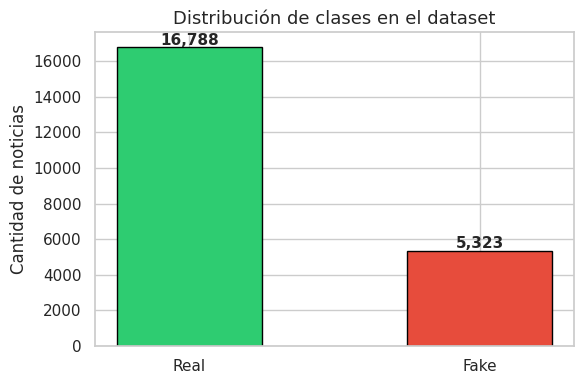


 ANALIZANDO LONGITUD DE LOS TÍTULOS...


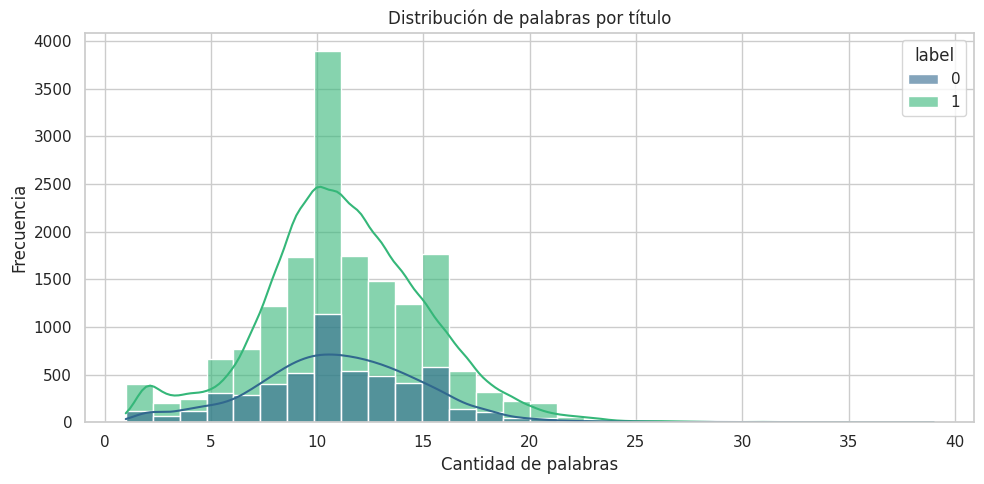

/tmp/ipykernel_11576/3976592497.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot( data=df, x='label', y='word_count', palette='viridis')


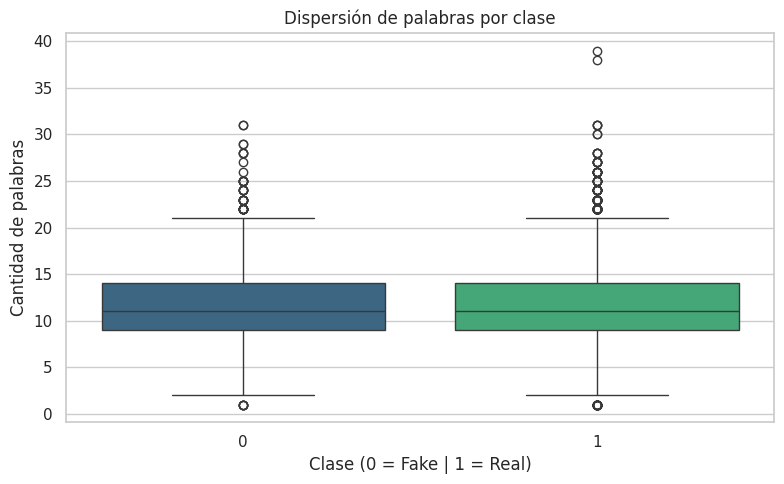

In [ ]:
print("\n INICIANDO EXPLORACIÓN DE DATOS (EDA)\n")
# 3.3.1 Valores nulos y duplicados

print(" VALORES NULOS POR COLUMNA")
print(df.isnull().sum().to_string())
print(f"\n REGISTROS DUPLICADOS: {df.duplicated().sum()}")

# 3.3.2 Distribución de clases

conteo = df['label'].value_counts().rename({1:'Real', 0:'Fake'})
pct = conteo / conteo.sum() * 100

print(f"\n DISTRIBUCIÓN DE CLASES")
print(f"  ▸ Noticias Reales : {conteo['Real']:>6} ({pct['Real']:.1f}%)")
print(f"  ▸ Noticias Falsas : {conteo['Fake']:>6} ({pct['Fake']:.1f}%)")

# Gráfico de distribución de clases

fig, ax = plt.subplots(figsize=(6, 4))
colores = ['#2ecc71', '#e74c3c']

barras = ax.bar( ['Real', 'Fake'], [conteo['Real'], conteo['Fake']],
    color=colores, edgecolor='black', width=0.5 )

for barra in barras:
    ax.text(
        barra.get_x() + barra.get_width()/2, barra.get_height() + 150,
        f'{barra.get_height():,}', ha='center', fontsize=11, fontweight='bold' )

ax.set_title('Distribución de clases en el dataset', fontsize=13)
ax.set_ylabel('Cantidad de noticias')

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════
# 3.3.3 Análisis de longitud de títulos
# ═══════════════════════════════════════════════════════════

print("\n ANALIZANDO LONGITUD DE LOS TÍTULOS...")
# Crear nueva columna con cantidad de palabras
df['word_count'] = df['title'].apply(lambda x: len(str(x).split()))

# Histograma
plt.figure(figsize=(10, 5))
sns.histplot( data=df, x='word_count', hue='label', bins=30, kde=True, palette='viridis', alpha=0.6 )

plt.title('Distribución de palabras por título')
plt.xlabel('Cantidad de palabras')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════
# 3.3.4 Detección de outliers
# ═══════════════════════════════════════════════════════════

plt.figure(figsize=(8, 5))
sns.boxplot( data=df, x='label', y='word_count', palette='viridis')

plt.title('Dispersión de palabras por clase')
plt.xlabel('Clase (0 = Fake | 1 = Real)')
plt.ylabel('Cantidad de palabras')

plt.tight_layout()
plt.show()


### 3.4 Hallazgos iniciales

In [ ]:
print("\n HALLAZGOS INICIALES DEL EDA\n")
print(f" Total de registros válidos: {len(df):,}")
print("\n Proporción de clases:")
print(df['label'].value_counts(normalize=True)
      .rename({1:'Real', 0:'Fake'})
      .apply(lambda x: f"{x*100:.2f}%")
      .to_string())

print("\n📝 Promedio de palabras por título:")
print(f"  ▸ Noticias Reales : {df[df['label']==1]['word_count'].mean():.2f} palabras")
print(f"  ▸ Noticias Falsas : {df[df['label']==0]['word_count'].mean():.2f} palabras")
print("\n✅ Exploración de datos completada correctamente.")



 HALLAZGOS INICIALES DEL EDA

 Total de registros válidos: 22,111

 Proporción de clases:
label
Real    75.93%
Fake    24.07%

📝 Promedio de palabras por título:
  ▸ Noticias Reales : 11.27 palabras
  ▸ Noticias Falsas : 11.03 palabras

✅ Exploración de datos completada correctamente.


#------------------------------------------
# PUNTO 4: PREPARACIÓN DE LOS DATOS
#------------------------------------------

In [ ]:
gossipcop_real = gossipcop_real.drop(columns=['Unnamed: 4', 'Unnamed: 5'], errors='ignore')
gossipcop_fake = gossipcop_fake.drop(columns=['Unnamed: 4', 'Unnamed: 5'], errors='ignore')

In [ ]:
print(real.head())
print(fake.head())

print(real.shape)
print(fake.shape)

                 id                                           news_url  \
0  gossipcop-882573  https://www.brides.com/story/teen-mom-jenelle-...   
1  gossipcop-875924  https://www.dailymail.co.uk/tvshowbiz/article-...   
2  gossipcop-894416        https://en.wikipedia.org/wiki/Quinn_Perkins   
3  gossipcop-857248  https://www.refinery29.com/en-us/2018/03/19192...   
4  gossipcop-884684  https://www.cnn.com/2017/10/04/entertainment/c...   

                                               title  \
0  Teen Mom Star Jenelle Evans' Wedding Dress Is ...   
1  Kylie Jenner refusing to discuss Tyga on Life ...   
2                                      Quinn Perkins   
3  I Tried Kim Kardashian's Butt Workout & Am For...   
4  Celine Dion donates concert proceeds to Vegas ...   

                                           tweet_ids  label  tipo_noticia  
0  912371411146149888\t912371528343408641\t912372...      1             1  
1  901989917546426369\t901989992074969089\t901990...      1       

In [ ]:
real = gossipcop_real.drop(columns=['Unnamed: 4', 'Unnamed: 5'], errors='ignore')
fake = gossipcop_fake.drop(columns=['Unnamed: 4', 'Unnamed: 5'], errors='ignore')

real['tipo_noticia'] = 1
fake['tipo_noticia'] = 0

df = pd.concat([real, fake], ignore_index=True)

df = df.dropna(subset=['title'])

df = df.drop_duplicates(subset=['title'])

Función de normalización

In [ ]:
def limpiar_texto(texto):

    texto = texto.lower()

    texto = re.sub(r'http\\S+', '', texto)

    texto = re.sub(r'\\d+', '', texto)

    texto = texto.translate(
        str.maketrans('', '', string.punctuation)
    )

    texto = re.sub(r'\\s+', ' ', texto).strip()

    return texto

Aplicación de la normalización

In [ ]:
df['title_clean'] = df['title'].apply(limpiar_texto)

In [ ]:
df['longitud_titulo'] = df['title_clean'].apply(len)

df['cantidad_palabras'] = df['title_clean'].apply(
    lambda x: len(x.split())
)

df['mayusculas'] = df['title'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper())
)

df['exclamaciones'] = df['title'].apply(
    lambda x: x.count('!')
)

In [ ]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X = vectorizer.fit_transform(df['title_clean'])

y = df['tipo_noticia']

Partición del Conjunto de Datos

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Verificación final

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(16572, 5000)
(4144, 5000)
tipo_noticia
1    12751
0     3821
Name: count, dtype: int64
tipo_noticia
1    3189
0     955
Name: count, dtype: int64


se guarda normalizado

In [ ]:
def save_dataframe_to_csv(dataframe, filename='Data_limpio.csv', index=False):

    dataframe.to_csv(filename, index=index)
    print(f"Guardado correctamente{filename}")

save_dataframe_to_csv(df, 'normalizado.csv')

Guardado correctamentenormalizado.csv


---
# PUNTO 5: Selección del Modelo
---
Para este problema de aprendizaje supervisado (clasificación binaria), se evaluaron modelos base y de ensamble, seleccionando finalmente Random Forest. Esta elección se justifica por su excelente manejo de la alta dimensionalidad generada por la vectorización TF-IDF, su capacidad para evitar el sobreajuste mediante la construcción de múltiples árboles, y su eficacia para tratar el desbalance de clases (noticias verdaderas frente a falsas) ajustando los pesos automáticamente con el parámetro class_weight='balanced'.

#### Definición del modelo base con pesos balanceados

In [ ]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

#### Definición del grid de hiperparámetros

In [ ]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 20, 30],
    'min_samples_split': [5, 10],
    'criterion': ['gini', 'entropy']
}

#### Configuración de validación cruzada estratificada

In [ ]:
cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

#### Configuración de GridSearchCV

In [ ]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv_strat,
    n_jobs=-1,
    scoring='precision',
    verbose=2
)
print("Entrenando con GridSearchCV. Esto puede tomar varios minutos...")
start_time = time.time()

Entrenando con GridSearchCV. Esto puede tomar varios minutos...


#### Ajuste del modelo

In [ ]:
grid_search.fit(X_train, y_train)
end_time = time.time()
print(f"Búsqueda finalizada en {(end_time - start_time) / 60:.2f} minutos.")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Búsqueda finalizada en 15.57 minutos.


#### Resultados y extracción del mejor modelo

In [ ]:
print("\n--- Resultados de la Búsqueda ---")
print(f"Mejores parámetros optimizados: {grid_search.best_params_}")
print(f"Mejor precisión obtenida: {grid_search.best_score_:.4f}")
best_rf_model = grid_search.best_estimator_


--- Resultados de la Búsqueda ---
Mejores parámetros optimizados: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10, 'n_estimators': 300}
Mejor precisión obtenida: 0.8834


#### Predicción con el dataset de pruebas usando el mejor modelo

In [ ]:
predict = best_rf_model.predict(X_test)

# ----------------------------
# Entrenamiento  del modelo
#--------------------------------------

In [ ]:

model = RandomForestClassifier()

### Validacion cruzada

In [ ]:
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores.mean())

0.8261245301886142


### Optimización de Hiperparámetros y Validación Cruzada
Utilizaremos GridSearchCV para encontrar la mejor combinación de parámetros para nuestro RandomForestClassifier

In [ ]:


param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 20, 30],
    'min_samples_split': [5, 10],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='precision',
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Mejores parámetros optimizados: {grid_search.best_params_}")
print(f"Mejor precisión obtenida: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Mejores parámetros optimizados: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10, 'n_estimators': 300}
Mejor precisión obtenida: 0.8853


### Entrenamiento de Random Forest

In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    criterion='gini',
    class_weight='balanced',
    random_state=42
)


model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_split=10,
                       n_estimators=300, random_state=42)

Prediccion con el dataset de pruebas

In [ ]:
predict = model.predict(X_test)